In [1]:
from manim import *
import jupyter_capture_output

video_scene = " -v WARNING --disable_caching tunnel_compression_Scene"
image_scene = f" -v WARNING --disable_caching -r {2*427},{2*240}  -s tunnel_compression_Scene"

Jupyter Capture Output v0.0.11


In [181]:
# parameters
l = 10				# tunnel length
width = 1			# half-width of the pressure pulse
v_t = 1.0			# train velocity
t_0 = 1.5			# time the pulse starts from the train etering the tunnel


# range of the left-running wave
def get_range_left(t_raw):
	# get the modulo of the time
	t = t_raw % (2*l / v_t)
	# x-center of the left-running wave
	wave_center = l - v_t*(t+t_0)
	# leftwards propagation only
	if t < (l-width) / v_t - t_0:
		return [wave_center-width, wave_center+width]
	# superposition on left
	elif (l-width) / v_t - t_0 < t and t < (l+width) / v_t - t_0:
		return [0, wave_center+width]
	# rightwards propagation only
	elif (l+width) / v_t - t_0 < t and t < (3*l-width) / v_t - t_0:
		return [0, 0]
	# superposition on right
	elif (3*l-width) / v_t - t_0 < t and t < (3*l+width) / v_t - t_0:
		return [v_t*(t+t_0) -3*l + width, 10]
	else:
		return ValueError
	

# range of the right-running wave
def get_range_right(t_raw):
	# get the modulo of the time
	t = t_raw % (2*l / v_t)
	# x-center of the left-running wave
	wave_center = v_t*(t+t_0) - l
	# leftwards propagation only
	if t < (l-width) / v_t - t_0:
		return [0, 0]
	# superposition on left
	elif (l-width) / v_t - t_0 < t and t < (l+width) / v_t - t_0:
		return [0, wave_center+width]
	# rightwards propagation only
	elif (l+width) / v_t - t_0 < t and t < (3*l-width) / v_t - t_0:
		return [wave_center-width, wave_center+width]
	# superposition on right
	elif (3*l-width) / v_t - t_0 < t and t < (3*l+width) / v_t - t_0:
		return [wave_center-width, 10]
	else:
		return ValueError


# baseline pressure
def baseline(x):
	return 0


# wave running to the left
def get_pressure_left(t):
	def pressure_left(x):
		p_left = -np.sin(x/width*2*PI-v_t*(t+t_0) + l)
		return p_left
	return pressure_left


# wave running to the right
def get_pressure_right(t):
	def pressure_right(x):
		p_right = np.sin(x/width*2*PI+v_t*(t+t_0) - l)
		return p_right
	return pressure_right

In [ ]:
class Tunnel(Mobject):
	def __init__(self, tunnel_center = np.array([0, 0, 0]), tunnel_height = 1, tunnel_width = 5, **kwargs):
		super().__init__(**kwargs)
        
		self.tunnel_center = tunnel_center
		self.tunnel_height = tunnel_height
		self.tunnel_width = tunnel_width
        
		print(self.tunnel_width, tunnel_width)
		upper_tunnel = Line(start = self.tunnel_center-self.tunnel_width/2*RIGHT+self.tunnel_height/2*UP, end = self.tunnel_center+self.tunnel_width/2*RIGHT+self.tunnel_height/2*UP, stroke_width = 4, stroke_color = BLACK)
		lower_tunnel = Line(start = self.tunnel_center-self.tunnel_width/2*RIGHT-self.tunnel_height/2*UP, end = self.tunnel_center+self.tunnel_width/2*RIGHT-self.tunnel_height/2*UP, stroke_width = 4, stroke_color = BLACK)
		railway = DashedLine(start = self.tunnel_center+self.tunnel_width/2*RIGHT-self.tunnel_height/2*UP, end = self.tunnel_center+(self.tunnel_width/2+3)*RIGHT-self.tunnel_height/2*UP, stroke_width = 4, stroke_color = GRAY)

		self.plot_range = [0, 10, 2]
		self.ax = Axes(x_length = self.tunnel_width, y_length = self.tunnel_height, x_range = self.plot_range, y_range = [-1, 1, 1], 
			axis_config = {"stroke_width": 1, "stroke_opacity": 1, "tip_width": 0.125, "tip_height": 0.125, "stroke_color": BLACK}).move_to(self.tunnel_center)
		self.add(self.ax, upper_tunnel, lower_tunnel, railway)
        


class TunnelPressure(Mobject):
	def __init__(self, tunnel_center = np.array([0, 0, 0]), tunnel_height = 1, tunnel_width = 5, **kwargs):
		super().__init__(**kwargs)
        
		self.tunnel_center = tunnel_center
		self.tunnel_height = tunnel_height
		self.tunnel_width = tunnel_width

		self.plot_range = [0, 10, 2]
		self.ax = Axes(x_length = self.tunnel_width, y_length = self.tunnel_height, x_range = self.plot_range, y_range = [-1, 1, 1], 
			axis_config = {"stroke_width": 1, "stroke_opacity": 1, "tip_width": 0.125, "tip_height": 0.125, "stroke_color": BLACK}).move_to(self.tunnel_center)
		self.add(self.ax)


	def show_pressure(self, t):
		pressure_left_func = get_pressure_left(t)
		pressure_right_func = get_pressure_left(t)
		pressure_plot = self.ax.plot(pressure_func, x_range = [*self.plot_range[:2]], stroke_color = PURE_RED)
		self.add(pressure_plot)

Manim Community v0.18.1

8.0 8.0


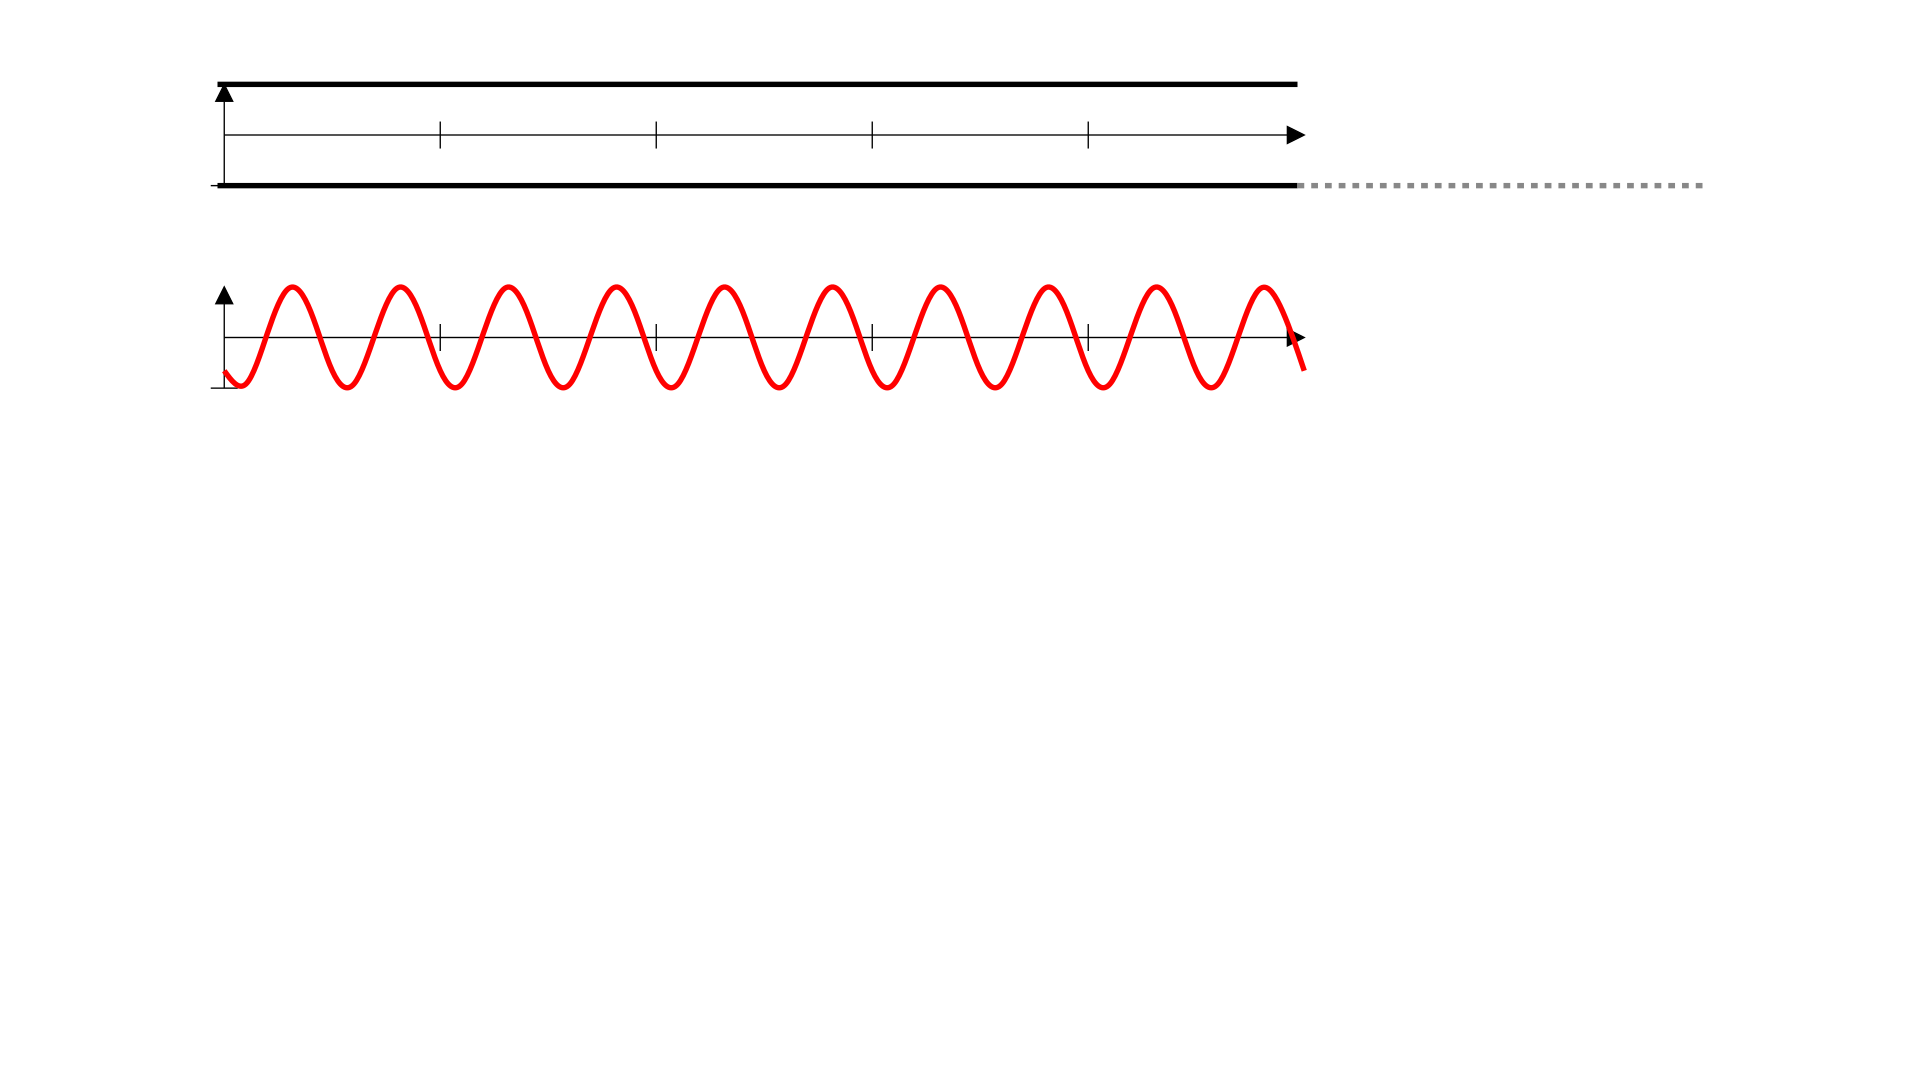

In [178]:
%%manim -qh --fps 60 $video_scene


class tunnel_compression_Scene(Scene):
	def construct(self):
		self.camera.background_color = WHITE

		CVC = Text('CVC', font_size = 12, weight = BOLD, color = WHITE, font = 'Latin Modern Sans').align_on_border(RIGHT + DOWN, buff = 0.2)
		self.add(CVC)


		tunnel_center = np.array([-1.5, 3, 0])
		tunnel_ax_center = np.array([-1.5, 1.5, 0])

		tunnel_height = 0.75
		tunnel_width = 8.0

		tunnel = Tunnel(tunnel_center = tunnel_center, tunnel_height = tunnel_height, tunnel_width = tunnel_width)
		tunnel_ax = TunnelPressure(tunnel_center = tunnel_ax_center, tunnel_height = 0.75, tunnel_width = tunnel_width)
		
		tunnel_ax_plot = tunnel_ax.show_pressure(1.5)
		self.add(tunnel, tunnel_ax)